<a href="https://colab.research.google.com/github/yenlikgaisina-ux/yg-consulting/blob/main/Copy_of_Sentiment_Analysis_Week_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp  "/content/drive/MyDrive/glove.twitter.27B.100d.txt" "/content/glove.twitter.27B.100d.txt"

# Week 1

This week you touched on things like:

1. **Preprocessing in NLP**
- `Preparing for NLP processing`

Before applying any NLP model, we need to prepare text data so it can be understood and processed effectively.

Tokenization is the process of breaking down a larger piece of text into smaller components such as words, phrases, or sub-words. These smaller units are called tokens.

For example:

`I love this course!" -> ["I", "love", "this", "course"]`

Tokens act as the building blocks for further analysis.

This step is particularly important for rule-based approaches, such as basic sentiment analysis, because these methods operate directly on individual words (tokens).

Stop words are very common words such as:

`"a", "an", "the", "and", "is", "in"`

These words typically do not add much meaning to NLP tasks like sentiment analysis.

For this reason, we often remove stop words from the text corpus to: Reduce noise; Improve processing efficiency; Focus on more meaningful words

For example:

`The movie was amazing" -> "movie amazing`

**Note**

Stop word removal is not always appropriate.

For example:

`"not good" -> removing "not"` changes the meaning completely

This highlights that preprocessing decisions depend on the task.

- Simplifying words and deriving meaning

After tokenizing text and removing unnecessary words, the next step is to standardise word forms so that similar words are treated as the same.

In natural language, words often appear in different forms. For example:

`“do”, “did”, “done”`

While these variations carry grammatical meaning for humans, they often don’t add value for many NLP tasks such as sentiment analysis.

To handle this, we apply techniques that normalize words by reducing them to a common base form.

**Stemming** reduces words to their root form by removing prefixes or suffixes.

Examples:

`“running” -> “run”`

`“played” -> “play”`

`“happiness” -> “happi”`

Notice that stemming can sometimes produce words that are not real dictionary words (e.g., “happi”).

It is a fast and simple method, but less precise.

**Lemmatization** reduces words to their dictionary (base) form, known as the lemma.

Examples:

`“running” -> “run”`

`“better” -> “good”`

`“did” -> “do”`

Unlike stemming, lemmatization:

`Produces real words`

`Uses linguistic rules and context (e.g., part of speech)`

`Is more accurate, but computationally more expensive`

By converting words to a common form, we:

`Reduce the size of the vocabulary`

`Group similar meanings together`

`Improve model performance and generalisation`

For example:

“I am running” and “I ran”
-> both map to “run”, helping the model recognise they are related

**Stemming** -> quick, rough trimming of words

**Lemmatization** -> slower, more accurate, linguistically informed

Normalising words helps models focus on meaning rather than form, which is essential for many NLP tasks.


2. **Word representations and the NLP pipeline**
- Creating representations with Bag of Words (BoW)

So far, we’ve cleaned and standardised our text.
But machine learning models cannot work directly with words, they need numbers.

This is where we convert text into a numerical representation.

Bag of Words (BoW) is a technique that converts text into numbers by counting how often each word appears in a document.

It creates a representation based purely on word frequency, ignoring:

`Word order`

`Grammar`

`Context`

*How It Works*

i) Build a vocabulary of all unique words in the dataset

ii) For each document, count how many times each word appears

iii) Represent each document as a vector of these counts

Consider two sentences:

`“I love NLP”`

`“I love machine learning”`

Vocabulary:

`[I, love, NLP, machine, learning]`

BoW representation:

| Sentence                | I | love | NLP | machine | learning |
| ----------------------- | - | ---- | --- | ------- | -------- |
| I love NLP              | 1 | 1    | 1   | 0       | 0        |
| I love machine learning | 1 | 1    | 0   | 1       | 1        |

Each sentence is now a numeric vector that a model can process.

BoW treats text as a “bag” of words, meaning:

`The order of words does not matter. only how often they appear.`

So:

`“dog bites man”`

`“man bites dog”`

would have the same representation

BoW allows us to:

`Convert text into a format usable by machine learning models`

`Capture important signals through word frequency`

`Build simple but effective models (e.g. sentiment analysis)`

While powerful, BoW has some drawbacks:

`Ignores word order and meaning`

`Cannot capture context`

`Vocabulary can become very large`

Bag of Words is one of the simplest and most important techniques in NLP:

`It transforms text into numbers by counting word occurrences.`

- Representing with Tf-idf

While Bag of Words counts how often words appear, it has a limitation:

`It treats all words as equally important.`

However, in reality, some words are more informative than others.

This is where TF-IDF comes in.

TF-IDF stands for Term Frequency – Inverse Document Frequency.

It is a technique that measures how important a word is:

`within a document, relative to a collection of documents (corpus)`

TF-IDF combines two ideas:

i) Term Frequency (TF): How often a word appears in a document.
`Words that appear more frequently in a document are considered more important.`

ii) Inverse Document Frequency (IDF): How rare a word is across all documents.
`Words that appear in many documents (e.g., “the”, “and”) are less useful`
`Words that appear in fewer documents are more informative`

TF-IDF increases weight when:

`A word appears frequently in a document`

`But rarely across the corpus`

And decreases weight when:

`A word appears everywhere`

Imagine analysing movie reviews:

`Word like “movie” -> appears in almost every review -> low importance`

`Word like “outstanding” -> appears less often -> high importance`

TF-IDF helps highlight the words that differentiate documents.

Key Difference from Bag of Words

`BoW -> counts frequency only`

`TF-IDF -> adjusts frequency by importance`

So instead of just counting words, TF-IDF asks:

`“Is this word actually useful for distinguishing this document?”`

TF-IDF:

`Reduces the impact of very common words`

`Highlights more meaningful and distinctive terms`

`Often improves model performance compared to basic BoW`

**TF-IDF** improves on **Bag of Words** by giving more weight to informative words and less weight to common ones.

3. **Perfoming sentiment analysis with vector embeddings**
- Sentiment analysis

Sentiment analysis is a natural language processing technique used to determine the emotional tone behind a body of text. It involves analysing text data to categorise opinions expressed as positive, negative, or neutral, thus providing insights into public sentiment or customer feedback. We will go through this today.

- Measuring similarity in words





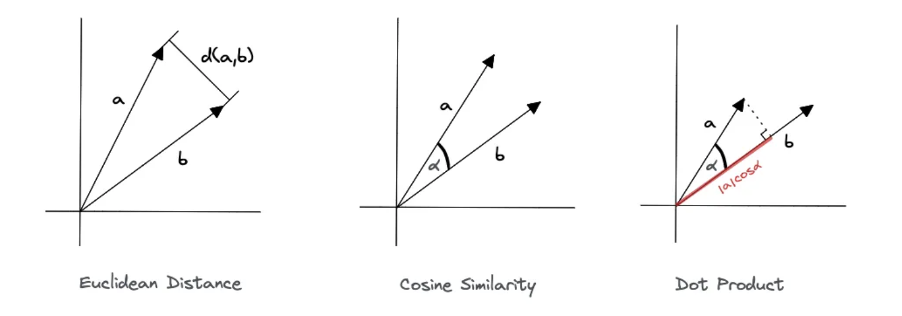

When working with text (or any data converted into vectors), we often need a way to answer a simple question:

`How similar are these two things?`

There are a few common ways to measure this, and each one looks at similarity slightly differently.

**Euclidean Distance**

Euclidean distance is the most intuitive one—it measures how far apart two points are.

Think of it like:

`The straight-line distance between two points on a graph`

`If two points are close together, they are considered similar`

`If they are far apart, they are considered different`

This method cares about the actual distance between points

Important thing to note:

`It is sensitive to scale`

`If one feature has much larger values than others, it can dominate the result`

That’s why we often normalize the data first

When is it useful?

`Clustering (grouping similar items)`

`Classification (finding nearest neighbours)`



**Cosine Similarity**

Cosine similarity looks at similarity in a different way.

Instead of asking:

`“How far apart are these points?”`

It asks:

`“Are these points pointing in the same direction?”`

`If two vectors point in the same direction, they are very similar`

`If they point in different directions, they are less similar`

It focuses on direction, not size

Why is this useful for text?

`In text data, longer documents naturally have larger values`

`But we usually care about what words are used, not how long the document is`

So cosine similarity:

`Ignores magnitude (length)`

`Focuses on pattern and meaning`

When is it useful?

`Text analysis`

`Search engines`

`Document similarity`

**Dot Product**

The dot product is a more direct way of measuring similarity.

It considers:

`Direction (like cosine similarity)`

`Magnitude (like Euclidean distance)`

So it answers:

`“How aligned are these vectors, and how large are they?”`

`Larger values -> more similar`

`Smaller values -> less similar`

It combines both size and alignment

Why use it?

`It’s very fast and simple to compute`

`Works well in high-dimensional data (like text vectors)`

When is it useful?

`Recommendation systems`

`Machine learning models`

`Situations where both strength and similarity matter`

Cosine Similarity:

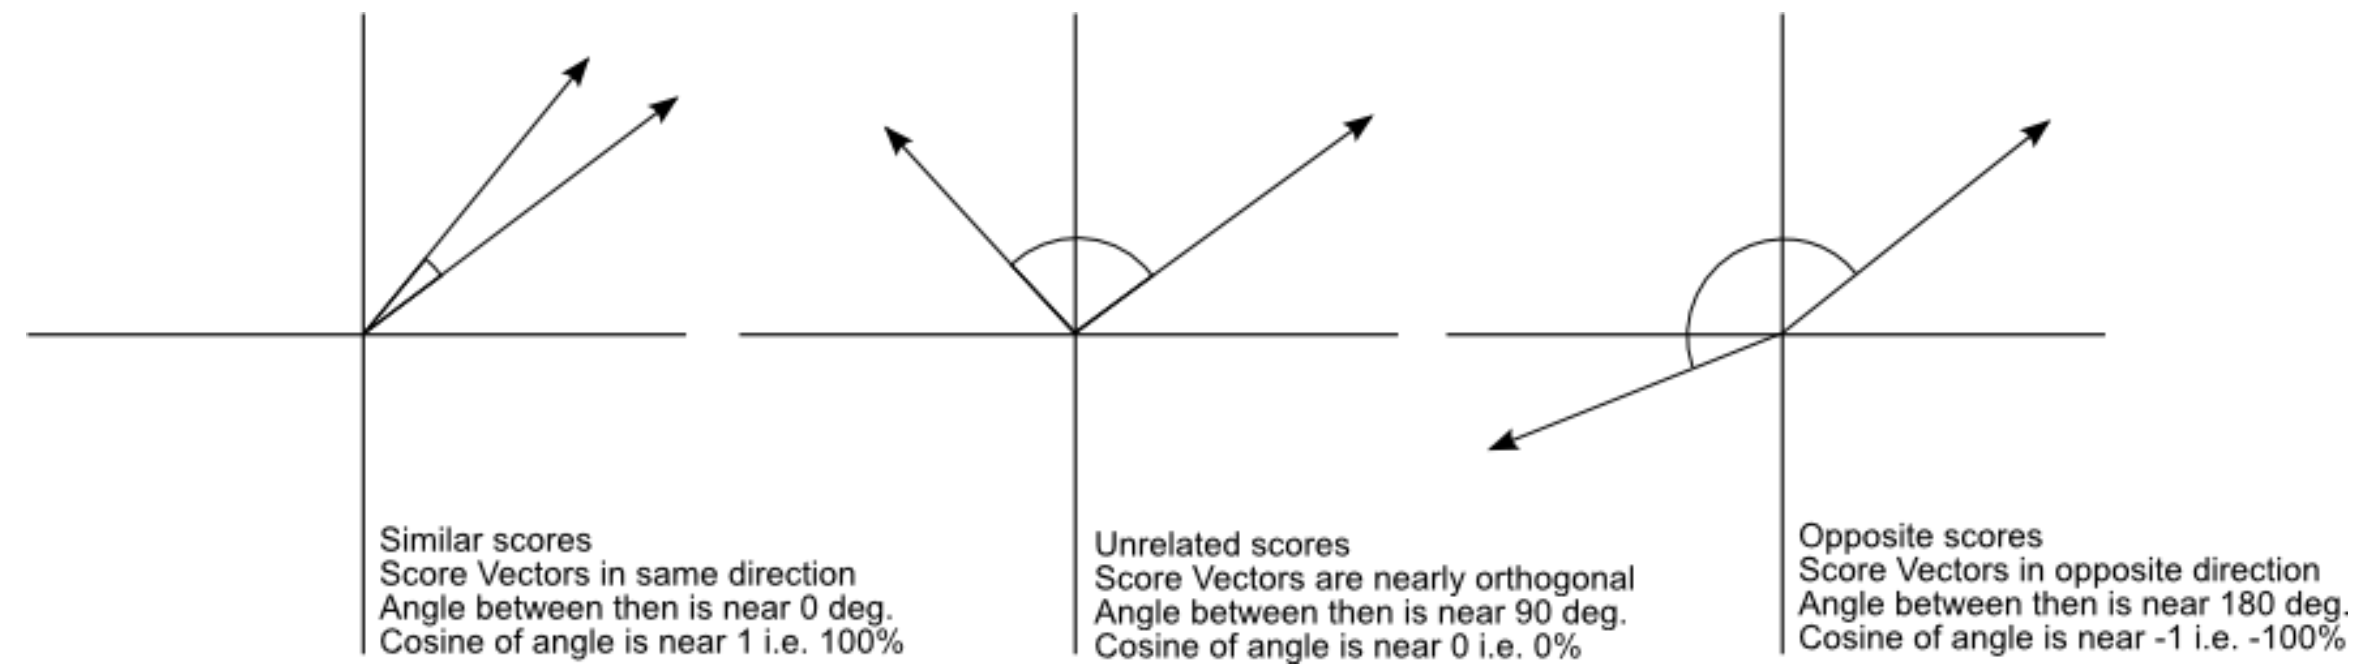

- Word embeddings: Word2Vec and GloVe





So far, we’ve converted text into numbers using methods like Bag of Words and TF-IDF.

However, these approaches have a limitation:

`They do not capture meaning or relationships between words.`

This is where word embeddings come in.

Word embeddings are dense vector representations of words, where:

`Each word is represented as a set of numbers`

`Words with similar meanings are located close together in space`

This allows models to understand relationships like:

`“king” is related to “queen”`

`“good” is similar to “great”`

Unlike BoW or TF-IDF, embeddings:

`Capture meaning and context`

`Understand similarity between words`

`Work well in more advanced NLP tasks`

**Word2Vec** is a model developed by Google that learns word relationships based on local context.

It works by looking at words and their surrounding words in sentences.

There are two main ideas:

`Predict a word from its surrounding words`

`Or predict surrounding words from a given word`

Words that appear in similar contexts end up with similar representations.

**GloVe (Global Vectors)** is a model developed at Stanford that learns word relationships using global statistics across the entire dataset.

Instead of just looking at nearby words, it considers:

`How often words appear together across all documents`

It captures broader relationships across the whole corpus.

Both Word2Vec and GloVe can learn relationships like:

`king − man + woman ≈ queen`

This shows that embeddings can capture meaningful patterns and analogies between words.

The key difference is that Word2Vec focuses on local context (nearby words) and GloVe uses global co-occurrence information (entire dataset)

Word embeddings allow models to:

`Understand meaning, not just word counts`

`Generalise better across language`

`Perform well on tasks like sentiment analysis, search, and recommendation`

Word embeddings move us from counting words to understanding meaning.



Today we will do a deep dive into **Sentiment Analysis**

# Sentiment Analysis



For any business, delivering great products and services is always the priority. But just as important is understanding **how customers actually feel** about what you’ve delivered.

Companies collect huge amounts of feedback from:

* Customer reviews
* Surveys
* Social media
* Support interactions

The challenge has always been making sense of this data. Manually reading and analysing large volumes of text is slow, expensive, and often inconsistent.

This is where **Natural Language Processing (NLP)** comes in.

Sentiment analysis is an NLP technique used to determine the **emotional tone** behind a piece of text. At its simplest, it classifies text as:

* Positive
* Negative
* Neutral

This allows businesses to quickly extract insight from large amounts of unstructured text.

---

In practice, sentiment analysis is used across many domains, including:

* Monitoring public opinion on social media
* Analysing customer feedback and reviews
* Understanding financial market sentiment
* Tracking political opinion
* Improving user engagement in digital products

---

Sentiment analysis itself can vary depending on the problem.

In its simplest form, we use:

* **Binary classification** i.e. positive vs negative
* **Multiclass classification** i.e. negative, neutral, positive (or even scaled ratings like 1–5)

In more advanced use cases, we use:

* **Aspect-based sentiment analysis**, where we look at sentiment towards specific features (e.g. *“food was great but service was terrible”*)

---

In real-world applications, sentiment analysis is often combined with other techniques such as:

* Emotion analysis (especially for negative feedback)
* Topic modelling to identify common themes
* Clustering to understand groups of users or behaviours

---

There are several ways to approach sentiment analysis:

**Rule-based approaches** rely on predefined dictionaries and rules.
These methods look for known positive and negative words and apply scoring logic.

They are:

* Easy to understand and interpret
* Quick to implement
* Flexible with or without labelled data

However, they:

* Depend heavily on domain knowledge
* Struggle with nuance, sarcasm, and context

A well-known example of this approach is **VADER**, which is particularly effective for social media text.

---

**Machine learning approaches** learn patterns from labelled data.

Traditional models (such as logistic regression or Naive Bayes) use features like Bag of Words or TF-IDF to classify sentiment. These models work well but have limited understanding of context.

More advanced models (such as neural networks) improve this by capturing patterns in sequences of text. However, they can still struggle with longer-term dependencies.

This led to the development of **transformer-based models**, which are now state-of-the-art for NLP tasks, including sentiment analysis.

---

**Hybrid approaches** combine rule-based systems with machine learning models.
These can be useful when domain expertise is important, allowing you to blend human knowledge with learned patterns.

---

In this session, we will explore these ideas in practice.

We will:

* Start with **VADER** to see how rule-based sentiment analysis works
* Move to **custom embeddings**, where we train our own representations
* Compare with **pre-trained embeddings (GloVe)** to see what additional value they bring
* Adjust and evaluate performance across approaches

One key takeaway you’ll see is that:

> More complex models don’t always guarantee dramatically better results, especially depending on the dataset.

Finally, we will look at **transformer-based models (e.g. BERT)**, which significantly improve performance by capturing deeper context—but at the cost of increased computational time.

---

Overall, this section is about understanding:

> The trade-offs between simplicity, performance, and computational cost in sentiment analysis.


# Imports

In [ ]:
import pandas as pd
import re
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud,STOPWORDS

nltk.download('vader_lexicon')
nltk.download('stopwords')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
sentiment_intensity_analyser = SentimentIntensityAnalyzer()
sns.set(rc={'figure.figsize':(30,1)})

def visualise_sentiments(data):
  sns.heatmap(pd.DataFrame(data).set_index("Prompt").T,center=0, annot=True, cmap = "PiYG")

In [ ]:
import numpy as np
import collections
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
import tensorflow as tf
#from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from keras import models
from keras import layers

# Data

- How travelers in February 2015 expressed their feeelings on Twiter
- Contains whether the sentiment of the tweets in this set was positive, neutral, or negative for six US airlines

**Data breakdown**:
- tweet_id (unique id - integer)
- airline_sentiment (e.g. positive, negative, neutral - string)
- airline_sentiment_confidence (e.g. between 0 and 1 - float)
- negativereason (e.g. Bad Flight, Can't Tell - string)
- negativereason_confidence (e.g. between 0 and 1 - float)
- airline (e.g. Virgin America - string)
- airline_sentiment_gold (e.g. negative, neutral, positive and mostly null - string)
- name (e.g. user names - string)
- negativereason_gold (e.g. Late Flight, Customer Service Issue and mostly null - string)
- retweet_count (e.g. 44 - integer)
- text (e.g. @VirginAmerica What @dhepburn said. - string)
- tweet_coord (e.g. [40.74804263, -73.99295302] - string)
- tweet_created (e.g. 2015-02-24 11:35:52 -0800 - string)
- tweet_location (e.g. Lets Play, San Francisco CA or null - string)
- user_timezone (e.g. Eastern Time (US & Canada), Pacific Time (US & Canada) - string)


Let's load our data into a dataframe.

In [ ]:
tweets = pd.read_csv("Tweets.csv")

Have a quick glance at the dataframe.

In [ ]:
tweets.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


# VADER

As you’ve seen, there are many ways to approach sentiment analysis.
Let’s now focus on one of the simplest—and most widely used—methods: **VADER**.

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a **rule-based sentiment analysis tool** that is particularly well-suited to **social media text**.

---

VADER works using a predefined **lexicon**, which is essentially a dictionary of words and phrases, each assigned a sentiment score.

To analyse a piece of text, VADER:

* Breaks the text into individual words
* Assigns a sentiment score to each word
* Combines these scores to produce an overall sentiment

---

One of the key strengths of VADER is that it doesn’t just look at words in isolation—it also considers **how sentiment is expressed**.

For example, it takes into account:

* Capitalisation (*“GREAT” vs “great”*)
* Punctuation (*“!!!”*)
* Modifiers (*“very good” vs “good”*)

This allows it to capture **intensity and emphasis**, which is particularly important in informal text like tweets.

---

The final sentiment score produced by VADER ranges from:

* **-1** i.e. very negative
* **+1** i.e. very positive

---

#### **Why Use VADER?**

* No training required
* Fast and efficient
* Easy to interpret
* Works well on short, informal text

This makes it a great **starting point** for sentiment analysis, especially in business settings where transparency matters.

---

#### **Limitations of VADER**

Like all models, VADER has its weaknesses.

It struggles with:

* **Sarcasm and irony**
* **Subtle negation** (e.g. *“not bad”*)
* **Complex language and context**
* **Multilingual text**

---

A good example of this came from a previous project using football tweets.
Despite trying multiple approaches, sarcasm and irony made accurate sentiment detection extremely difficult. In many cases, **emojis carried more meaning than the text itself**.

This highlights an important point:

`Understanding human language is hard—even for well-designed models.`

---

#### **What We’ll Do Next**

You’ve already seen the tweet dataset, so now we’ll apply VADER in practice using **NLTK (Natural Language Toolkit)**.

NLTK is a powerful Python library that provides tools for many NLP tasks, including:

* Tokenization
* Preprocessing
* Sentiment analysis (via VADER)

We’ll use it to:

* Analyse sentiment in airline tweets
* Explore how VADER performs
* Identify where it works well—and where it struggles



# VADER - NLTK

- First, we import Natural Language Toolkit (NLTK). NLTK is a 'leading platform for building Python programs to work with human language data. It provides easy-to-use interfaces to over 50 corpora and lexical resources such as WordNet. It also provides a suite of text processing libraries for classification, tokenization, stemming, tagging, parsing and semantic reasoning, wrappers for industrial-strength NLP libraries and an active discussion forum.'

- Here we also download the vader_lexicon. VADER means Valence Aware Dictionary and sEntiment Reasoner. VADER belongs to a kind of sentiment analysis that depends on lexicons of sentiment-related words.

- We will use the SentimentIntensityAnalyzer to check the sentiment of our prompts.

Let's test out NLTK's VADER on a fake prompt.

In [ ]:
prompt = "I love this new product."

We can visualise the sentiment scores against the prompt, per word.

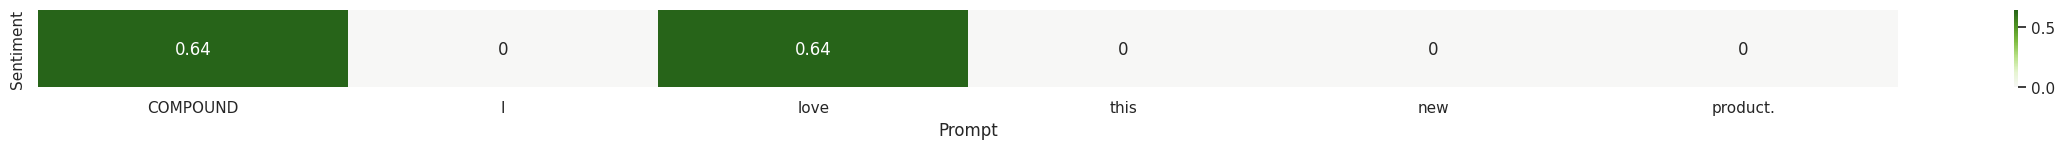

In [ ]:
visualise_sentiments({
    "Prompt":["COMPOUND"] + prompt.split(),
    "Sentiment":[sentiment_intensity_analyser.polarity_scores(prompt)["compound"]] + [sentiment_intensity_analyser.polarity_scores(word)["compound"] for word in prompt.split()]
})

Obviously, we can get this from a map using the **polarity_scores()** method.

In [ ]:
sentiment_intensity_analyser.polarity_scores(prompt)

{'neg': 0.0, 'neu': 0.417, 'pos': 0.583, 'compound': 0.6369}

This returns the following scores, which give us a sense of the prompt sentiment.

{'neg': 0.0, 'neu': 0.417, 'pos': 0.583, 'compound': 0.6369}

The prompt started with 'I love this...', so it might be surprising to see that this analysis is quite high in neutral (neu). It is also mostly positive (pos) and this is further reaffirmed when we look at the compound, which shows that the sentiment is positive. The compound is a metric that is a normalised value of all ratings, and it ranges from -1 (negative) to 1 (positive). Our compound value here is closer to 1, so we infer that it is positive.

Where -ve (-1, -0.05), neutral (-0.05, 0.05) and +ve (0.05, 1), this essentially means that anything from -1 to -0.05 is negative, -0.05 to 0.05 is neutral and anything from 0.05 to 1 is positive.

From our data, we identify that text, which is the actual tweet, and airline_sentiment, which is labelled already as positive, negative or neutral, are the most useful.

So, we will make a copy of the tweets dataframe and extract these two columns.

In [ ]:
vader_df = tweets.copy()
vader_df_cleaned = vader_df[['text', 'airline_sentiment']]

I will also write a quick function to remove things like mentions, hash symbols, hyperlinks etc.

In [ ]:
def cleantxt(text):
    text= re.sub(r'@[A-Za-z0-9]+', '',text)# removed @mentions
    text= re.sub(r'#', '',text)# removed # symbol
    text = re.sub(r'https?:\/\/\s+', '',text)# removed the hyperlink
    text = re.sub(r':+', '',text)# removed : symbol
    text = re.sub(r'--+', '',text)# removed : symbol
    text = re.sub(r'http', '',text)
    return text


Then I can apply this to update the text in the text column.

In [ ]:
vader_df_cleaned["text"] = vader_df_cleaned["text"].apply(cleantxt)

/tmp/ipykernel_476/1239699493.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vader_df_cleaned["text"] = vader_df_cleaned["text"].apply(cleantxt)


Let's have a little peak of our cleaned data.

In [ ]:
vader_df_cleaned.head()

,text,airline_sentiment
0,What said.,neutral
1,plus you've added commercials to the experien...,positive
2,I didn't today... Must mean I need to take an...,neutral
3,"it's really aggressive to blast obnoxious ""en...",negative
4,and it's a really big bad thing about it,negative


Next, we want to run our text through VADER find out the sentiment that it considers the text to have. I will write a function to find the sentiment score and classify it as positive, negative or neutral.

In [ ]:
def predicted_sentiment_score(text):
  compound = sentiment_intensity_analyser.polarity_scores(text)["compound"]
  sentiment = 'neutral'
  if (compound >= 0.05):
    sentiment = "positive"
  elif (compound <= -0.05):
    sentiment = "negative"

  return sentiment

Apply this to the dataframe and add a new column.

In [ ]:
vader_df_cleaned["nltk"] = vader_df_cleaned["text"].apply(predicted_sentiment_score)

/tmp/ipykernel_476/764699932.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vader_df_cleaned["nltk"] = vader_df_cleaned["text"].apply(predicted_sentiment_score)


Now let's check our dataframe.

In [ ]:
vader_df_cleaned.head()

,text,airline_sentiment,nltk
0,What said.,neutral,neutral
1,plus you've added commercials to the experien...,positive,neutral
2,I didn't today... Must mean I need to take an...,neutral,neutral
3,"it's really aggressive to blast obnoxious ""en...",negative,negative
4,and it's a really big bad thing about it,negative,negative


Great, we can see one "wrongly" classified tweet, but who says the labels were correct. Also, if it is a reply, we don't consider this as it will miss context.

Next, let's get a simple score by measuring how many neutrals, positives and negatives were correctly classified.

In [ ]:
neutrals = vader_df_cleaned[vader_df_cleaned["airline_sentiment"] == "neutral"]
neutrals_accuracy = len(neutrals[neutrals["airline_sentiment"] == neutrals["nltk"]])/len(neutrals)
print("neutrals_accuracy", neutrals_accuracy)

neutrals_accuracy 0.42787996127783157


In [ ]:
negatives = vader_df_cleaned[vader_df_cleaned["airline_sentiment"] == "negative"]
negatives_accuracy = len(negatives[negatives["airline_sentiment"] == negatives["nltk"]])/len(negatives)
print("negatives_accuracy", negatives_accuracy)

negatives_accuracy 0.5052298975811723


In [ ]:
positives = vader_df_cleaned[vader_df_cleaned["airline_sentiment"] == "positive"]
positives_accuracy = len(positives[positives["airline_sentiment"] == positives["nltk"]])/len(positives)
print("positives_accuracy", positives_accuracy)

positives_accuracy 0.8700804062632247


In [ ]:
acc = (negatives_accuracy+positives_accuracy)/2
print("nltk accuracy", acc)

nltk accuracy 0.6876551519221985


Overall, the accuracy here wasn't great. Positives was 87% accurate, but negatives was only 50% accurate and neutrals only 43% accurate.

We should probably dig into this futher, but for now, we can safely assume that NLTK's implementation of VADER is probably underperforming with just an accuracy of 60% and that context will be needed to get better results i.e. replies etc. Also, removing tagging may actually be detrimetal as it may show a particular behaviour.

# Sentiment Analysis with vector embeddings

Let's start off again by making a copy of the original tweets dataframe.

In [ ]:
embed_df = tweets.copy()

Since we are going to be training a model here, we should randomise the data a little. We can do that using .reindex()

Also, since we know that text and airline_sentiment are our inputs and our labels, we will make a new dataframe with a randomised index and just these columns.

In [ ]:
embed_df = embed_df.reindex(np.random.permutation(embed_df.index))
embed_df = embed_df[['text', 'airline_sentiment']]

Next, we need to do some of the pre-processing we discussed earlier, like removing stopwords and mentions.

Let's write a couple of functions and apply them to the dataframe.

For remove_stopwords, we can use nltk, but as mentioned before, this gets a little bit nuanced and we are going to keep a few in a whitelist that can be used to indicate sentiment.

In [ ]:
def remove_stopwords(input_text):
    stopwords_list = stopwords.words('english')
    whitelist = ["n't", "not", "no"]
    words = input_text.split()
    clean_words = [word for word in words if (word not in stopwords_list or word in whitelist) and len(word) > 1]
    return " ".join(clean_words)

For remove_mentions, we use regex (regular expression) as before. Obviously, we could do more, but this will be fine.

In [ ]:
def remove_mentions(input_text):
    return re.sub(r'@\w+', '', input_text)

Let's apply these to the dataframe.

In [ ]:
embed_df.text = embed_df.text.apply(remove_stopwords).apply(remove_mentions)

Next, we are going to use train_test_split to make training and test input and output sets. We are setting a random state for reproducibility and also the test size, where we will go for 0.1, which may be a little low.

In [ ]:
input_train, input_test, label_train, label_test = train_test_split(embed_df.text, embed_df.airline_sentiment, test_size=0.1, random_state=37)

Now we will define a number of parameters:

- **number_of_words**: indicates the number of words we will put in the dictionary.
- **validation_size**: size of the validation set.
- **number_of_epochs**: number of epochs we start to train with.
- **batch_size**: size of the batches used in the mini-batch gradient descent.
- **max_word_length**: maximum numbr of words in a sequence.
- **num_glove_dimensions**: number of dimensions of the GloVe word embeddings

At the moment, our parameters are a little arbitrary.


In [ ]:
number_of_words = 10000
validation_size = 1000
number_of_epochs = 10
batch_size = 512
max_word_length = 24
num_glove_dimensions = 100

Create a tokenizer. We have added a filter and converted all text to lower case and split on a space

In [ ]:
tokenizer = Tokenizer(num_words=number_of_words, filters='!"#$%&()*+,-./:;<=>?@[\]^_`{"}~\t\n', lower=True, split=" ")

<>:1: SyntaxWarning: invalid escape sequence '\]'
<>:1: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_476/903449481.py:1: SyntaxWarning: invalid escape sequence '\]'
  tokenizer = Tokenizer(num_words=number_of_words, filters='!"#$%&()*+,-./:;<=>?@[\]^_`{"}~\t\n', lower=True, split=" ")


Let's fit on our training data.

In [ ]:
tokenizer.fit_on_texts(input_train)

Let's create our input sequences for both our training and test datasets.

In [ ]:
input_train_seq = tokenizer.texts_to_sequences(input_train)
input_test_seq = tokenizer.texts_to_sequences(input_test)

In [ ]:
print("input_train_seq", input_train_seq)
print("input_test_seq", input_test_seq)

input_train_seq [[176, 155, 57, 35, 6055, 4283, 130, 202, 135, 565, 14, 57, 268, 420], [785, 4284, 728, 4285], [117, 61, 1, 38, 202, 827, 489, 2886, 587], [64, 191, 464, 1273, 18, 377, 4286, 58, 59, 115, 369, 494, 346, 193, 1111], [142], [130, 4287, 828, 729, 152, 203, 122, 16, 40, 1, 113, 149, 9, 33], [24, 90, 291, 991, 3436, 99, 6056, 1151, 588], [87, 204, 520, 334, 627, 1942], [382, 190], [3437, 450, 2106, 1152, 266, 1802, 50, 335, 266, 690, 85, 149, 61, 21], [690, 383, 786, 2887, 1213, 2], [113, 1328, 336, 1112, 238, 1680, 337, 2107, 311, 13, 2281, 1803], [108, 29, 4, 82, 38, 653, 202, 935], [22, 399, 194, 936, 501, 188, 128, 1, 246], [56, 69, 62, 400, 384, 279, 6057, 127, 105, 1153, 1274], [6058, 28, 321, 65, 75, 31, 2537, 787, 1214, 1804, 288, 6059, 69, 2538], [280, 788, 168, 346, 1681, 884, 6060], [318, 81, 279, 1405, 3438, 63, 37, 145, 76, 1, 2, 4, 279, 416, 352, 4288, 12], [22, 123, 37, 1031, 654], [1, 60], [1275, 112, 18, 566, 6061, 385, 465, 127, 83, 84, 1576, 219], [18, 425

As you can see, we have different lengths. For our batches, we need to have the same length of inputs so let's use pad sequences to our max_word_length set earlier

In [ ]:
input_train_seq_trunc = pad_sequences(input_train_seq, maxlen=max_word_length)
input_test_seq_trunc = pad_sequences(input_test_seq, maxlen=max_word_length)

In [ ]:
print("input_train_seq_trunc", input_train_seq_trunc)
print("input_test_seq_trunc", input_test_seq_trunc)

input_train_seq_trunc [[   0    0    0 ...   57  268  420]
 [   0    0    0 ... 4284  728 4285]
 [   0    0    0 ...  489 2886  587]
 ...
 [   0    0    0 ...  877  286  421]
 [   0    0    0 ... 1145   11 4687]
 [   0    0    0 ...  478  629 1681]]
input_test_seq_trunc [[   0    0    0 ... 1090   22   11]
 [   0    0    0 ...  110  814   42]
 [   0    0    0 ...    0  256  259]
 ...
 [   0    0    0 ...    7    5    6]
 [   0    0    0 ...    0    0    8]
 [   0    0    0 ...   93   26  121]]


Next, we need LabelEncoder. Label encoding is a simple and effective way to convert categorical variables into numerical form.

In [ ]:
label_encoder = LabelEncoder()

In [ ]:
label_train_label_encoded = label_encoder.fit_transform(label_train)
label_test_label_encoded = label_encoder.transform(label_test)

In [ ]:
print("label_train_label_encoded", label_train_label_encoded)
print("label_test_label_encoded", label_test_label_encoded)

label_train_label_encoded [0 2 0 ... 2 0 0]
label_test_label_encoded [2 0 1 ... 1 2 0]


Next, we one hot encode:

In [ ]:
label_train_one_hot_encoded = to_categorical(label_train_label_encoded)
label_test_one_hot_encoded = to_categorical(label_test_label_encoded)

In [ ]:
print("label_train_one_hot_encoded", label_train_one_hot_encoded)
print("label_test_one_hot_encoded", label_test_one_hot_encoded)

label_train_one_hot_encoded [[1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]]
label_test_one_hot_encoded [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


Ok, so next, let's get our train and validation splits for our embedded inputs and one_hot_encoded outputs.

In [ ]:
input_train_emb, input_valid_emb, label_train_emb, label_valid_emb = train_test_split(input_train_seq_trunc, label_train_one_hot_encoded, test_size=0.1, random_state=37)

Let's create our Sequential model using Keras.

**Firstly, we have our Embedding layer. It must specify 3 arguments:**

- **input_dim**: This is the size of the vocabulary in the text data. For example, if your data is integer encoded to values between 0-10, then the size of the vocabulary would be 11 words.
- **output_dim**: This is the size of the vector space in which words will be embedded. It defines the size of the output vectors from this layer for each word. For example, it could be 32 or 100 or even larger. Test different values for your problem.
- **input_length**: This is the length of input sequences, as you would define for any input layer of a Keras model. For example, if all of your input documents are comprised of 1000 words, this would be 1000.

**Next, we have a flatten layer:**

Flattening a tensor means to remove all of the dimensions except for one.

A Flatten layer in Keras reshapes the tensor to have a shape that is equal to the number of elements contained in the tensor.

This is the same thing as making a 1d-array of elements.

**Lastly, we have a dense layer using softmax activation function:**

Softmax converts a vector of values to a probability distribution.

The elements of the output vector are in range [0, 1] and sum to 1.

Each input vector is handled independently. The axis argument sets which axis of the input the function is applied along.

Softmax is often used as the activation for the last layer of a classification network because the result could be interpreted as a probability distribution.

In [ ]:
embeddings_model = models.Sequential()
embeddings_model.add(layers.Embedding(number_of_words, 8, input_length=max_word_length))
embeddings_model.add(layers.Flatten())
embeddings_model.add(layers.Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Let's check out our model

In [ ]:
embeddings_model.build(input_shape=(None, 24))

In [ ]:
embeddings_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 24, 8)          │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           579 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,579 (314.76 KB)

 Trainable params: 80,579 (314.76 KB)

 Non-trainable params: 0 (0.00 B)

Great, the model expects an input of length 24 with an output of length 3 where the values are between 0 and 1. Exactly as we exepect.

Since we will want to make different models but still carry out the same process, let's make a function to facilitate this.

One thing you could do here is change the optimizer i.e. rmsprop

In [ ]:
def model_train(model, input_train, label_train, input_valid, label_valid):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(input_train, label_train, epochs=number_of_epochs, batch_size=batch_size, validation_data=(input_valid, label_valid), verbose=0)

    return history

Ok, so let's train our model.

In [ ]:
embeddings_history = model_train(embeddings_model, input_train_emb, label_train_emb, input_valid_emb, label_valid_emb)

In [ ]:
sns.set(rc={'figure.figsize':(5,5)})

Now, let's check out our results.

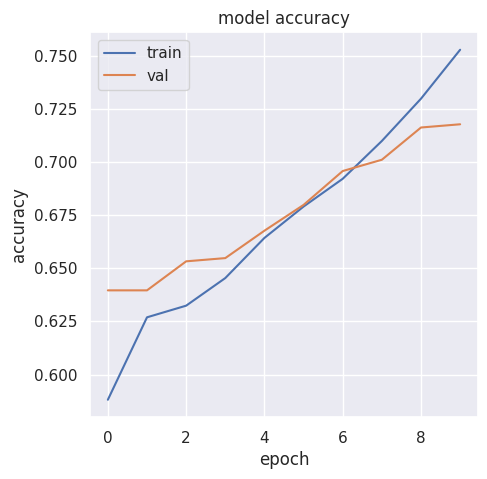

In [ ]:
plt.plot(embeddings_history.history['accuracy'])
plt.plot(embeddings_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

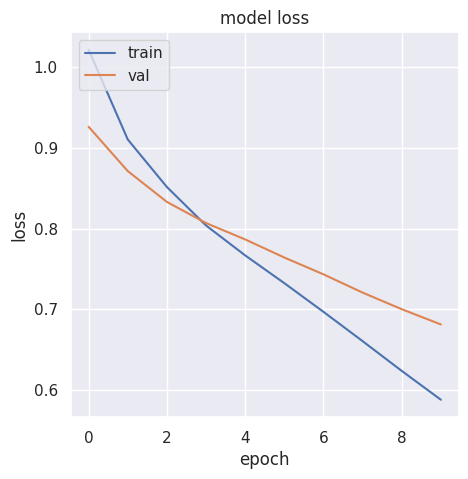

In [ ]:
plt.plot(embeddings_history.history['loss'])
plt.plot(embeddings_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Looks like some potential overfitting after epoch 5. Let's try our model against our test data using 5 as epoch_stop.

let's try our model against our test data

In [ ]:
def model_test(model, input_train, label_train, input_test, label_test, epoch_stop):
    model.fit(input_train, label_train, epochs=epoch_stop, batch_size=batch_size, verbose=0)
    results = model.evaluate(input_test, label_test)

    return results

In [ ]:
embeddings_results = model_test(embeddings_model, input_train_seq_trunc, label_train_one_hot_encoded, input_test_seq_trunc, label_test_one_hot_encoded, 5)
print('/n')
print('Test accuracy of word embeddings model: {0:.2f}%'.format(embeddings_results[1]*100))

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7719 - loss: 0.5889
/n
Test accuracy of word embeddings model: 77.19%


80% accuracy is pretty good. It seems our Sentiment Analysis with Vector Embeddings has outperfomed our rules-based VADER approach, although the test isn't quite the same.

Now, let's take some pre-canned Glove vector embeddings.

For example, the researchers behind GloVe method provide a suite of pre-trained word embeddings on their website released under a public domain license.

- GloVe: Global Vectors for Word Representation
The smallest package of embeddings is 822Mb, called “glove.6B.zip“. It was trained on a dataset of one billion tokens (words) with a vocabulary of 400 thousand words. There are a few different embedding vector sizes, including 50, 100, 200 and 300 dimensions.

- You can download this collection of embeddings and we can seed the Keras Embedding layer with weights from the pre-trained embedding for the words in your training dataset.

We will be using 100 dimensions. We neeed to upload the file glove.twitter.27B.100d.txt, which can take a bit of time.


In [ ]:
glove_file = 'glove.twitter.27B.' + str(num_glove_dimensions) + 'd.txt'
embeddings_dict = {}
glove = open(glove_file)
for line in glove:
    values = line.split()
    word = values[0]
    vector = np.asarray(values[1:], dtype='float32')
    embeddings_dict[word] = vector
glove.close()

Let's do a quick check for some words to make sure that this method will be useful. Remember we are using air travel tweets.

In [ ]:
airline_words = ['airplane', 'airline', 'flight', 'luggage']
for w in airline_words:
  if w in embeddings_dict.keys():
    print('Found the word {} in the dictionary'.format(w))

Found the word airplane in the dictionary
Found the word airline in the dictionary
Found the word flight in the dictionary
Found the word luggage in the dictionary


Perfect! Now, let's check for any words not in the pre-trained word embeddings and add them.

In [ ]:
embeddings_matrix = np.zeros((number_of_words, num_glove_dimensions))
for w, i in tokenizer.word_index.items():
  if i < number_of_words:
    vect = embeddings_dict.get(w)
    if vect is not None:
      embeddings_matrix[i] = vect
  else:
    break

Now, let's do the same again, but using the number of glove dimensions.

In [ ]:
glove_model = models.Sequential()
glove_model.add(layers.Embedding(number_of_words, num_glove_dimensions, input_length=max_word_length))
glove_model.add(layers.Flatten())
glove_model.add(layers.Dense(3, activation='softmax'))

We need to set the weights of the Embedding layer and make sure that the weights are then not updated during training by setting trainable to False.

In [ ]:
glove_model.layers[0].build(embeddings_matrix.shape)
glove_model.layers[0].set_weights([embeddings_matrix])
glove_model.layers[0].trainable = False
glove_history = model_train(glove_model, input_train_emb, label_train_emb, input_valid_emb, label_valid_emb)

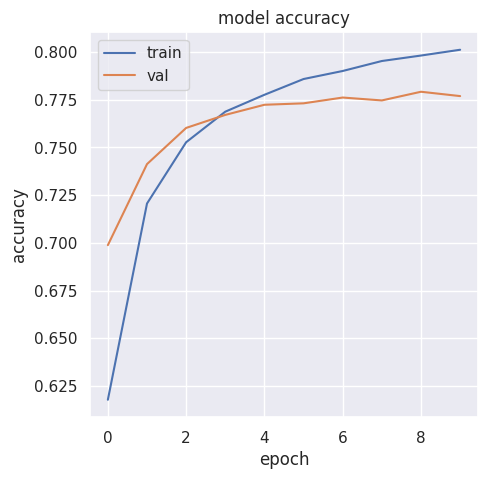

In [ ]:
plt.plot(glove_history.history['accuracy'])
plt.plot(glove_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

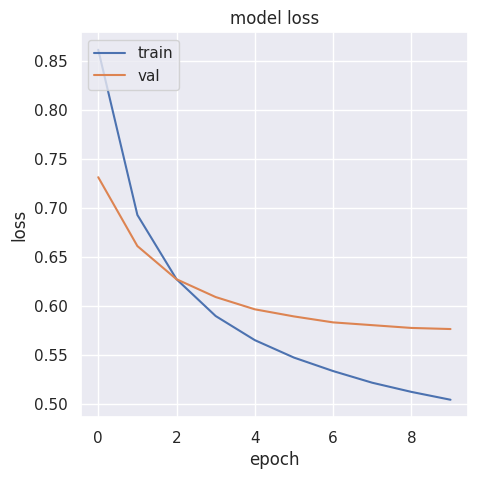

In [ ]:
plt.plot(glove_history.history['loss'])
plt.plot(glove_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

looks like it training a little faster. Lets take epoch 3 for stopping in our test.

In [ ]:
glove_results = model_test(glove_model, input_train_seq_trunc, label_train_one_hot_encoded, input_test_seq_trunc, label_test_one_hot_encoded, 3)
print('/n')
print('Test accuracy of word glove model: {0:.2f}%'.format(glove_results[1]*100))

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7418 - loss: 0.6289
/n
Test accuracy of word glove model: 74.18%


Well, it seems we got a less accurate result, but not by much. Let's try again, with our embeddings but with 100 dimensions.

The dimensions in GloVe embeddings refer to the size of the vector used to represent each word — for example, 100D means each word is mapped to a 100-element vector. Higher dimensions can capture more semantic nuance but may also risk overfitting if your dataset is small. If you're getting less accurate results, trying 100D is a good step — it's a common balance between expressiveness and efficiency.

In [ ]:
embeddings_model2 = models.Sequential()
embeddings_model2.add(layers.Embedding(number_of_words, num_glove_dimensions, input_length=max_word_length))
embeddings_model2.add(layers.Flatten())
embeddings_model2.add(layers.Dense(3, activation='softmax'))

In [ ]:
embeddings_history2 = model_train(embeddings_model2, input_train_emb, label_train_emb, input_valid_emb, label_valid_emb)

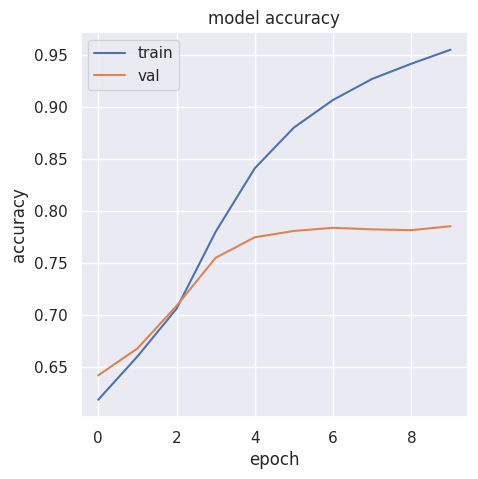

In [ ]:
plt.plot(embeddings_history2.history['accuracy'])
plt.plot(embeddings_history2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

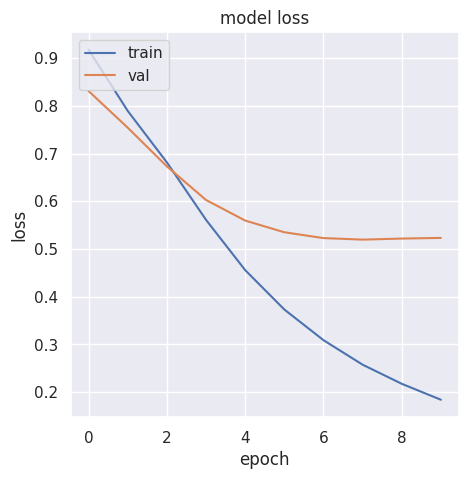

In [ ]:
plt.plot(embeddings_history2.history['loss'])
plt.plot(embeddings_history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Well, it converges quite quickly and there is some overfitting after epoch 2. So let's take epoch 3 when testing.

In [ ]:
embeddings_results2 = model_test(embeddings_model2, input_train_seq_trunc, label_train_one_hot_encoded, input_test_seq_trunc, label_test_one_hot_encoded, 3)
print('/n')
print('Test accuracy of word embedding model 2: {0:.2f}%'.format(embeddings_results2[1]*100))

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7766 - loss: 0.5699
/n
Test accuracy of word embedding model 2: 77.66%


A pretty much identical result to the earlier model with only 8 dimensions. We can see that the model accuracy goes up on the training data into the 90%'s, but on the test data we are getting closer to the accuracy we perceived in our first model.

However, there is still room for improvement.

Until now we have just used a Dense layer on the flattened embeddings.

By doing this, we do not take into account the relationships between the words in the tweet.

This can be done with an RNN, for example. Which you will get to in coming weeks.

# Some interesting quirks with VADER

So, let's go back to VADER for a few moments.

In [ ]:
prompt = "I love to hate this product."

In [ ]:
sentiment_intensity_analyser.polarity_scores(prompt)

{'neg': 0.339, 'neu': 0.275, 'pos': 0.385, 'compound': 0.128}

This would classify as somewhat positive overall where it is clearly negative. Highlighting the issues mentioned earlier.

Another important thing to note about VADER is that it is quite sophisticated in terms of its workings. For example, it takes into account negation words and is specialised to social media snippets. So if we review the lexicon, we can see things like smiley faces added using special characters. You can scroll all the way to the end to see some examples.

In [ ]:
print(sentiment_intensity_analyser.lexicon)

{'$:': -1.5, '%)': -0.4, '%-)': -1.5, '&-:': -0.4, '&:': -0.7, "( '}{' )": 1.6, '(%': -0.9, "('-:": 2.2, "(':": 2.3, '((-:': 2.1, '(*': 1.1, '(-%': -0.7, '(-*': 1.3, '(-:': 1.6, '(-:0': 2.8, '(-:<': -0.4, '(-:o': 1.5, '(-:O': 1.5, '(-:{': -0.1, '(-:|>*': 1.9, '(-;': 1.3, '(-;|': 2.1, '(8': 2.6, '(:': 2.2, '(:0': 2.4, '(:<': -0.2, '(:o': 2.5, '(:O': 2.5, '(;': 1.1, '(;<': 0.3, '(=': 2.2, '(?:': 2.1, '(^:': 1.5, '(^;': 1.5, '(^;0': 2.0, '(^;o': 1.9, '(o:': 1.6, ")':": -2.0, ")-':": -2.1, ')-:': -2.1, ')-:<': -2.2, ')-:{': -2.1, '):': -1.8, '):<': -1.9, '):{': -2.3, ');<': -2.6, '*)': 0.6, '*-)': 0.3, '*-:': 2.1, '*-;': 2.4, '*:': 1.9, '*<|:-)': 1.6, '*\\0/*': 2.3, '*^:': 1.6, ',-:': 1.2, "---'-;-{@": 2.3, '--<--<@': 2.2, '.-:': -1.2, '..###-:': -1.7, '..###:': -1.9, '/-:': -1.3, '/:': -1.3, '/:<': -1.4, '/=': -0.9, '/^:': -1.0, '/o:': -1.4, '0-8': 0.1, '0-|': -1.2, '0:)': 1.9, '0:-)': 1.4, '0:-3': 1.5, '0:03': 1.9, '0;^)': 1.6, '0_o': -0.3, '10q': 2.1, '1337': 2.1, '143': 3.2, '1432': 2.

Let's see what the sentiment intensity analyser brings when we try to represent grinning using special characters, like in ":D". Based on the example below, this looks like a positive sentiment.

In [ ]:
sentiment_intensity_analyser.polarity_scores(":D")

{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.5106}

However, the scores are very different when we use an emoji instead of special characters.

In [ ]:
sentiment_intensity_analyser.polarity_scores('😀')

{'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0}

You can see that something is not right here when we use emojis, as there is no sentiment score shown at all. To handle this, we will use the actual VADER project.

In [ ]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.6 MB/s eta 0:00:00


In [ ]:
sentiment_intensity_analyzer_vader = SentimentIntensityAnalyzer()

With everything in place now, let's have a look at the lexicon again.

In [ ]:
print(sentiment_intensity_analyzer_vader.lexicon)

{'$:': -1.5, '%)': -0.4, '%-)': -1.5, '&-:': -0.4, '&:': -0.7, "( '}{' )": 1.6, '(%': -0.9, "('-:": 2.2, "(':": 2.3, '((-:': 2.1, '(*': 1.1, '(-%': -0.7, '(-*': 1.3, '(-:': 1.6, '(-:0': 2.8, '(-:<': -0.4, '(-:o': 1.5, '(-:O': 1.5, '(-:{': -0.1, '(-:|>*': 1.9, '(-;': 1.3, '(-;|': 2.1, '(8': 2.6, '(:': 2.2, '(:0': 2.4, '(:<': -0.2, '(:o': 2.5, '(:O': 2.5, '(;': 1.1, '(;<': 0.3, '(=': 2.2, '(?:': 2.1, '(^:': 1.5, '(^;': 1.5, '(^;0': 2.0, '(^;o': 1.9, '(o:': 1.6, ")':": -2.0, ")-':": -2.1, ')-:': -2.1, ')-:<': -2.2, ')-:{': -2.1, '):': -1.8, '):<': -1.9, '):{': -2.3, ');<': -2.6, '*)': 0.6, '*-)': 0.3, '*-:': 2.1, '*-;': 2.4, '*:': 1.9, '*<|:-)': 1.6, '*\\0/*': 2.3, '*^:': 1.6, ',-:': 1.2, "---'-;-{@": 2.3, '--<--<@': 2.2, '.-:': -1.2, '..###-:': -1.7, '..###:': -1.9, '/-:': -1.3, '/:': -1.3, '/:<': -1.4, '/=': -0.9, '/^:': -1.0, '/o:': -1.4, '0-8': 0.1, '0-|': -1.2, '0:)': 1.9, '0:-)': 1.4, '0:-3': 1.5, '0:03': 1.9, '0;^)': 1.6, '0_o': -0.3, '10q': 2.1, '1337': 2.1, '143': 3.2, '1432': 2.

Like with the lexicon above, this is not easy to explore here. To have a better look of the VADER emoji lexicon, you can visit this link on [Github](https://github.com/cjhutto/vaderSentiment/blob/master/vaderSentiment/emoji_utf8_lexicon.txt)

**Note: when emojis are described in more than one word, the VADER algorhithm typically takes the first word as a key in the VADER lexicon.

Previously in the NLTK-VADER section, we faced a limitation of sentiment analysis when working with emojis. You can see now that with this version of VADER, we get some scores and a compound that is positive.

In [ ]:
sentiment_intensity_analyzer_vader.polarity_scores('😀')

{'neg': 0.0, 'neu': 0.286, 'pos': 0.714, 'compound': 0.3612}

The above example is great news. What we should take note from that is that not all packages which sell themselves as all-encompassing should be taken as the best option. There are clear things that some packages can or cannot do and it is worth exploring those limitations before adopting one.

Now, let's see how we can update the lexicon. Updating the lexicon can actually help us amend the scores of the words and emojis. For example, let's take decreasing which represents this emoji: 📉

In [ ]:
sentiment_intensity_analyzer_vader.emojis.get('📉')

'chart decreasing'

When we check the polarity of this, we get the example below.

In [ ]:
sentiment_intensity_analyzer_vader.polarity_scores('📉')

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

Let's say that in our corpus, we know that 'decreasing' means something negative. From the example above, we can see that the compound is neutral. In fact, we can see that this term doesn't exist when we get the following error.

In [ ]:
print(sentiment_intensity_analyzer_vader.lexicon["decreasing"])

KeyError: 'decreasing'

To fix this, we will need to update this in our lexicon. We need to make a new word map, with the key "decreasing" and giving a value representing a negative score (in this case -4.0).

We then use the update method in the lexicon package.

In [ ]:
new_words = {
    'decreasing': -4.0,
}

sentiment_intensity_analyzer_vader.lexicon.update(new_words)

Now, if we pass in the 'chart decreasing' emoji, we get a -ve (negative) compound.

In [ ]:
sentiment_intensity_analyzer_vader.polarity_scores('📉')

{'neg': 0.833, 'neu': 0.167, 'pos': 0.0, 'compound': -0.7184}

This means that perhaps we can adjust VADER to perhaps get better results where tweets include emojis.

# BERT

**You will go into this in a couple of weeks ... just a sneak peak for now**

In [ ]:
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import numpy as np
from scipy.special import softmax
import csv
import urllib.request

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment")
model = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def preprocess(text):
  new_text = []
  for t in text.split(" "):
    t = '@user' if t.startswith('@') and len(t) > 1 else t
    t = 'http' if t.startswith('http') else t
    new_text.append(t)
  return " ".join(new_text)

In [ ]:
#text = "Good night 😊"
text = prompt
text = preprocess(text)
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
print("[negative neutral positive]")
print(scores)

[negative neutral positive]
[0.9620482  0.03173255 0.00621924]


In [ ]:
from transformers import pipeline
sentiment_pipeline = pipeline("sentiment-analysis")


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
data = vader_df_cleaned["text"].values

In [ ]:
print(data)

[' What  said.'
 " plus you've added commercials to the experience... tacky."
 " I didn't today... Must mean I need to take another trip!" ...
 ' Please bring American Airlines to BlackBerry10'
 " you have my money, you change my flight, and don't answer your phones! Any other suggestions so I can make my commitment??"
 ' we have 8 ppl so we need 2 know how many seats are on the next flight. Plz put us on standby for 4 people on the next flight?']


In [ ]:
# The next cell took 19 minutes

In [ ]:
output = sentiment_pipeline(list(data))

In [ ]:
print(output)

[{'label': 'POSITIVE', 'score': 0.9785860776901245}, {'label': 'POSITIVE', 'score': 0.9709692001342773}, {'label': 'NEGATIVE', 'score': 0.9988656044006348}, {'label': 'NEGATIVE', 'score': 0.9992433786392212}, {'label': 'NEGATIVE', 'score': 0.9996041655540466}, {'label': 'NEGATIVE', 'score': 0.9652171730995178}, {'label': 'POSITIVE', 'score': 0.9824223518371582}, {'label': 'NEGATIVE', 'score': 0.9997929930686951}, {'label': 'POSITIVE', 'score': 0.9870474338531494}, {'label': 'POSITIVE', 'score': 0.999661922454834}, {'label': 'NEGATIVE', 'score': 0.9961189031600952}, {'label': 'POSITIVE', 'score': 0.9996615648269653}, {'label': 'POSITIVE', 'score': 0.9813678860664368}, {'label': 'POSITIVE', 'score': 0.9995197057723999}, {'label': 'POSITIVE', 'score': 0.9998165965080261}, {'label': 'NEGATIVE', 'score': 0.9989219903945923}, {'label': 'POSITIVE', 'score': 0.9958651065826416}, {'label': 'NEGATIVE', 'score': 0.9981880784034729}, {'label': 'POSITIVE', 'score': 0.9457551836967468}, {'label': 'P

In [ ]:
def get_label(obj):
  return obj["label"].lower()

In [ ]:
vader_df_cleaned["bert"] = output

/tmp/ipykernel_5601/1754529720.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vader_df_cleaned["bert"] = output


In [ ]:
vader_df_cleaned["bert"] = vader_df_cleaned["bert"].apply(get_label)

/tmp/ipykernel_5601/2441154647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vader_df_cleaned["bert"] = vader_df_cleaned["bert"].apply(get_label)


In [ ]:
vader_df_cleaned.head()

,text,airline_sentiment,nltk,bert
0,What said.,neutral,neutral,positive
1,plus you've added commercials to the experien...,positive,neutral,positive
2,I didn't today... Must mean I need to take an...,neutral,neutral,negative
3,"it's really aggressive to blast obnoxious ""en...",negative,negative,negative
4,and it's a really big bad thing about it,negative,negative,negative


In [ ]:
negatives = vader_df_cleaned[vader_df_cleaned["airline_sentiment"] == "negative"]
negatives_accuracy = len(negatives[negatives["airline_sentiment"] == negatives["bert"]])/len(negatives)
print("negatives_accuracy", negatives_accuracy)

negatives_accuracy 0.9068424493353672


In [ ]:
positives = vader_df_cleaned[vader_df_cleaned["airline_sentiment"] == "positive"]
positives_accuracy = len(positives[positives["airline_sentiment"] == positives["bert"]])/len(positives)
print("positives_accuracy", positives_accuracy)

positives_accuracy 0.841726618705036


In [ ]:
acc = (negatives_accuracy+positives_accuracy)/2
print("bert accuracy", acc)

bert accuracy 0.8742845340202016
